# Full-Dataset Model Comparison (De Chazal Split)

This notebook is the unified, full-dataset comparison of all the anomaly
detectors developed in the per-model notebooks (01-06). Unlike those notebooks,
which run on a small 5-record subset to validate the pipeline, this one uses the
**whole non-paced database** under the **De Chazal (2004) inter-patient split**:

- **Train**: normal beats from DS1 records only (semi-supervised setup).
- **Test**: all beats from DS2 records (normal + anomaly), completely unseen patients.

All models are scored by reconstruction/prediction error and share the same
evaluation protocol, so the numbers here are the reliable ones (the subset
results are volatile pipeline checks).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_all_mit_bih_records,
    create_beat_dataset,
    split_by_record_lists,
    evaluate_anomaly_detection,
)
from models import (
    PCAReconstructionAnomalyDetector,
    LSTMAutoencoderAnomalyDetector,
    VAEAnomalyDetector,
    CfCAutoencoderAnomalyDetector,
    ARMAModel,
)

## Experiment Configuration

`QUICK_TEST = True` runs a fast pipeline check (small subsample, few epochs).
Set it to **`False`** for the real full-dataset run (~40-55 min on a GTX 1650);
training shows a live progress bar (`verbose=True`).

In [2]:
QUICK_TEST = True  # <-- set to False for the full-dataset run

if QUICK_TEST:
    N_TRAIN_NORMAL = 3000          # cap on DS1 normal beats used for training
    BATCH_SIZE = 128
    EPOCHS_LSTM, EPOCHS_VAE, EPOCHS_CFC = 5, 5, 3
    ARMA_PER_CLASS = 300           # ARMA test beats per class
    print("QUICK_TEST: small subsample / few epochs (pipeline check, not final).")
else:
    N_TRAIN_NORMAL = None          # None = all DS1 normal beats (~45.8k)
    BATCH_SIZE = 256
    EPOCHS_LSTM, EPOCHS_VAE, EPOCHS_CFC = 30, 30, 20
    ARMA_PER_CLASS = None          # None = all DS2 anomalies + matched normals
    print("FULL run: all DS1 normals, full epochs (~40-55 min).")

QUICK_TEST: small subsample / few epochs (pipeline check, not final).


## Load Data and Apply the De Chazal Split

In [3]:
records = load_all_mit_bih_records(config.MIT_BIH_PATH)
dataset = create_beat_dataset(records, normalize=True)

X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("Total beats:", len(X))

Loading record 100...
Loading record 101...
Loading record 103...
Loading record 105...
Loading record 106...


Loading record 108...
Loading record 109...
Loading record 111...
Loading record 112...
Loading record 113...


Loading record 114...
Loading record 115...
Loading record 116...
Loading record 117...
Loading record 118...


Loading record 119...
Loading record 121...
Loading record 122...
Loading record 123...
Loading record 124...


Loading record 200...
Loading record 201...
Loading record 202...
Loading record 203...
Loading record 205...


...

Loading record 213...
Loading record 214...
Loading record 215...
Loading record 219...
Loading record 220...


Loading record 221...
Loading record 222...
Loading record 223...


Loading record 228...
Loading record 230...
Loading record 231...
Loading record 232...


Loading record 233...
Loading record 234...


Total beats: 100708


In [4]:
split = split_by_record_lists(X, y, metadata, config.DE_CHAZAL_DS1, config.DE_CHAZAL_DS2)

X_test, y_test = split["X_test"], split["y_test"]

# Training input: normal beats from DS1 only.
rng = np.random.default_rng(config.RANDOM_SEED)
X_train_normal = split["X_train"][split["y_train"] == 0]
rng.shuffle(X_train_normal)
if N_TRAIN_NORMAL is not None:
    X_train_normal = X_train_normal[:N_TRAIN_NORMAL]

print("DS1 train records:", len(config.DE_CHAZAL_DS1), "| DS2 test records:", len(config.DE_CHAZAL_DS2))
print("Normal training beats:", len(X_train_normal))
print("Test beats:", len(X_test),
      "| normal:", int((y_test == 0).sum()),
      "| anomaly:", int((y_test == 1).sum()))

DS1 train records: 22 | DS2 test records: 22
Normal training beats: 3000
Test beats: 49698 | normal: 44246 | anomaly: 5452


## Train and Evaluate Each Model

Every model is trained on the DS1 normal beats and scored on the DS2 test set.
The threshold is the 95th percentile of the model's score on its normal training
beats. We collect, for each model: ROC-AUC and PR-AUC (threshold-independent
ranking quality) and precision / recall / F1 at the 95th-percentile operating
point.

In [5]:
results = {}
curves = {}

def record_result(name, y_true, scores, threshold):
    """Evaluate a model and store its metrics and ROC/PR curve data."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    y_pred = (scores > threshold).astype(int)
    m = evaluate_anomaly_detection(y_true, y_pred, scores)
    results[name] = {
        "ROC-AUC": m["roc_auc"], "PR-AUC": m["pr_auc"],
        "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
    }
    curves[name] = (y_true, scores)
    print(f"{name:8} | ROC-AUC {m['roc_auc']:.3f} | PR-AUC {m['pr_auc']:.3f} | "
          f"P {m['precision']:.3f}  R {m['recall']:.3f}  F1 {m['f1']:.3f}")

### PCA (linear baseline)

In [6]:
pca = PCAReconstructionAnomalyDetector(
    n_components=8, threshold_percentile=95, random_state=config.RANDOM_SEED,
)
pca.fit(X_train_normal)
record_result("PCA", y_test, pca.anomaly_score(X_test), pca.threshold)

PCA      | ROC-AUC 0.731 | PR-AUC 0.192 | P 0.214  R 0.335  F1 0.262


### LSTM Autoencoder

In [7]:
lstm = LSTMAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN, hidden_size=16, latent_dim=8,
    epochs=EPOCHS_LSTM, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
)
lstm.fit(X_train_normal, verbose=True)
record_result("LSTM-AE", y_test, lstm.anomaly_score(X_test), lstm.threshold)

Epoch 1/5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/5:   4%|▍         | 1/24 [00:00<00:05,  4.10it/s]

Epoch 1/5 - loss: 0.0893


Epoch 2/5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 2/5 - loss: 0.0777


...

Epoch 4/5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 4/5 - loss: 0.0438


Epoch 5/5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 5/5 - loss: 0.0316


LSTM-AE  | ROC-AUC 0.713 | PR-AUC 0.502 | P 0.961  R 0.263  F1 0.413


### Variational Autoencoder

In [8]:
vae = VAEAnomalyDetector(
    input_dim=config.BEAT_LEN, hidden_size=64, latent_dim=8, beta=1.0,
    epochs=EPOCHS_VAE, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
)
vae.fit(X_train_normal, verbose=True)
record_result("VAE", y_test, vae.anomaly_score(X_test), vae.threshold)

Epoch 1/5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/5:   4%|▍         | 1/24 [00:00<00:02,  9.87it/s]

Epoch 1/5:  62%|██████▎   | 15/24 [00:00<00:00, 84.49it/s]

Epoch 1/5 - loss: 14.3205


Epoch 2/5:   0%|          | 0/24 [00:00<?, ?it/s]

...

Epoch 4/5 - loss: 5.4246


Epoch 5/5:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 5/5:  83%|████████▎ | 20/24 [00:00<00:00, 197.76it/s]

Epoch 5/5 - loss: 5.0886


VAE      | ROC-AUC 0.835 | PR-AUC 0.540 | P 0.884  R 0.295  F1 0.442


### CfC (Liquid) Autoencoder

In [9]:
cfc = CfCAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN, hidden_size=16, latent_dim=8,
    epochs=EPOCHS_CFC, batch_size=BATCH_SIZE, random_state=config.RANDOM_SEED,
)
cfc.fit(X_train_normal, verbose=True)
record_result("CfC-AE", y_test, cfc.anomaly_score(X_test), cfc.threshold)

Epoch 1/3:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/3:   4%|▍         | 1/24 [00:00<00:08,  2.62it/s]

Epoch 1/3:   8%|▊         | 2/24 [00:00<00:07,  2.86it/s]

Epoch 1/3:  12%|█▎        | 3/24 [00:01<00:07,  2.69it/s]

Epoch 1/3:  17%|█▋        | 4/24 [00:01<00:07,  2.54it/s]

...

Epoch 3/3:  92%|█████████▏| 22/24 [00:07<00:00,  2.85it/s]

Epoch 3/3:  96%|█████████▌| 23/24 [00:07<00:00,  2.84it/s]

Epoch 3/3: 100%|██████████| 24/24 [00:08<00:00,  2.87it/s]

Epoch 3/3 - loss: 0.0567


CfC-AE   | ROC-AUC 0.577 | PR-AUC 0.407 | P 0.992  R 0.248  F1 0.397


### ARMA (classical baseline)

ARMA fits one model per beat (~120 ms/beat), so scoring the whole DS2 test set
would take ~100 min. Since the ARMA score is independent per beat, we evaluate it
on a stratified sample of DS2 (all anomalies + a matched random sample of
normals), which is statistically representative. Its row in the table is
therefore computed on this sample, not on the full DS2.

In [10]:
arma = ARMAModel(
    p=config.ARIMA_P, d=config.ARIMA_D, q=config.ARIMA_Q, threshold_percentile=95,
)
arma.fit(X_train_normal[:300])  # threshold from a sample of normal training beats

anom_idx = np.where(y_test == 1)[0]
norm_idx = np.where(y_test == 0)[0]
rng_arma = np.random.default_rng(config.RANDOM_SEED)
rng_arma.shuffle(anom_idx)
rng_arma.shuffle(norm_idx)

n_per_class = len(anom_idx) if ARMA_PER_CLASS is None else ARMA_PER_CLASS
arma_idx = np.concatenate([anom_idx[:n_per_class], norm_idx[:n_per_class]])

X_arma, y_arma = X_test[arma_idx], y_test[arma_idx]
print(f"ARMA evaluated on {len(X_arma)} test beats "
      f"({int((y_arma==1).sum())} anomaly + {int((y_arma==0).sum())} normal)")
record_result("ARMA", y_arma, arma.anomaly_score(X_arma), arma.threshold)

ARMA evaluated on 600 test beats (300 anomaly + 300 normal)


ARMA     | ROC-AUC 0.321 | PR-AUC 0.403 | P 0.233  R 0.023  F1 0.042


## Results Table

In [11]:
results_df = pd.DataFrame(results).T
results_df = results_df[["ROC-AUC", "PR-AUC", "precision", "recall", "f1"]]
results_df = results_df.sort_values("ROC-AUC", ascending=False)
display(results_df.style.format("{:.3f}").background_gradient(cmap="Greens", subset=["ROC-AUC", "PR-AUC", "f1"]))

,ROC-AUC,PR-AUC,precision,recall,f1
VAE,0.835,0.540,0.884,0.295,0.442
PCA,0.731,0.192,0.214,0.335,0.262
LSTM-AE,0.713,0.502,0.961,0.263,0.413
CfC-AE,0.577,0.407,0.992,0.248,0.397
ARMA,0.321,0.403,0.233,0.023,0.042


## ROC and Precision-Recall Curves

These curves are threshold-independent: they show how well each model's score
*ranks* anomalies, across all possible operating points.

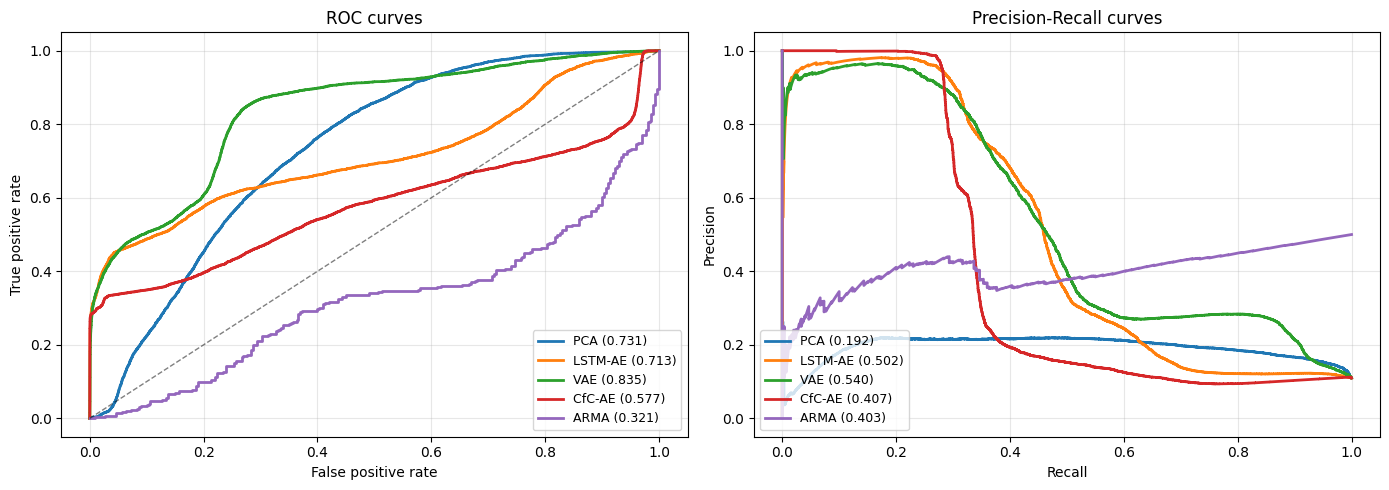

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (yt, sc) in curves.items():
    fpr, tpr, _ = roc_curve(yt, sc)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} ({results[name]['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

for name, (yt, sc) in curves.items():
    prec, rec, _ = precision_recall_curve(yt, sc)
    axes[1].plot(rec, prec, lw=2, label=f"{name} ({results[name]['PR-AUC']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Score Distributions

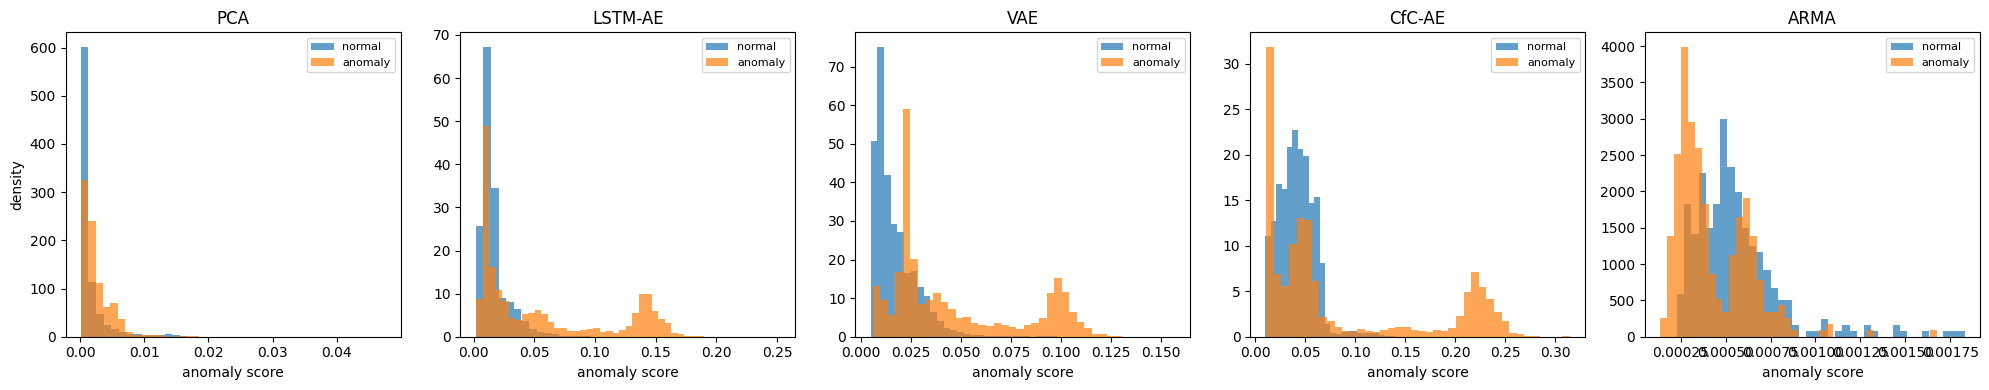

In [13]:
fig, axes = plt.subplots(1, len(curves), figsize=(4 * len(curves), 4), squeeze=False)

for ax, (name, (yt, sc)) in zip(axes[0], curves.items()):
    ax.hist(sc[yt == 0], bins=40, alpha=0.7, label="normal", density=True)
    ax.hist(sc[yt == 1], bins=40, alpha=0.7, label="anomaly", density=True)
    ax.set_title(name)
    ax.set_xlabel("anomaly score")
    ax.legend(fontsize=8)

axes[0][0].set_ylabel("density")
plt.tight_layout()
plt.show()

## Discussion

- These full-dataset, inter-patient results are the reliable ones. They are
  expected to be **much more modest** than the 5-record subset numbers, because
  the subset's test record (106) was dominated by easy high-energy ventricular
  beats, while DS2 includes subtle supraventricular (SVEB) anomalies.
- ROC-AUC / PR-AUC measure ranking quality independently of the threshold; the
  precision / recall / F1 columns reflect the fixed 95th-percentile operating
  point and depend on it.
- ARMA is evaluated on a representative DS2 sample (compute), the others on the
  full DS2.
- The contamination analysis (notebook 08) studies how injecting anomalies into
  the training set degrades each model — a robustness comparison on top of this
  clean-training baseline.